# DiffBind: Differential Binding Analysis


In [1]:
library(DiffBind)
    library(DESeq2)
    library(ChIPseeker)
    library(GenomicFeatures)
    library(org.Mm.eg.db)
    library(ggplot2)
    library(dplyr)
    library(readr)
    library(tibble)

# --- change this to run a different factor ---
TF <- 'Junb'   

# --- paths ---
MANIFEST  <- '../0_samplesheets/sample_manifest.tsv'
BAM_DIR   <- '../2_aligned'
PEAK_DIR  <- '../3_peaks'
GTF       <- '../igenomes/Mus_musculus/UCSC/mm10/Annotation/Genes/genes.gtf'
OUT_DIR   <- '0_outputs'

PEAK_TYPE   <- "relaxed"
PEAK_SUFFIX <- paste0(".seacr.peaks.", PEAK_TYPE, ".bed")

# --- settings ---
TSS_UP     <- 3000    # bp upstream of TSS for promoter annotation
TSS_DOWN   <- 3000    # bp downstream of TSS for promoter annotation
FDR_THRESH <- 0.05

dir.create(OUT_DIR, showWarnings=FALSE)
cat('Running TF:', TF, '\n')

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loa

Running TF: Junb 


In [2]:
manifest <- read_tsv(MANIFEST, show_col_types = FALSE)

build_samplesheet <- function(tf_manifest, bam_dir, peak_dir) {
    # nf-core names samples as {group}_R{replicate}, e.g. GFP_H3K4me3_R1
    nf_id <- paste0(tf_manifest$sample_name, '_R', sub('.*_', '', tf_manifest$sample_id))
    data.frame(
        SampleID   = tf_manifest$sample_id,
        Tissue     = tf_manifest$tf[1],
        Factor     = tf_manifest$tf[1],
        Condition  = tf_manifest$group,
        Replicate  = ave(tf_manifest$sample_id, tf_manifest$group, FUN = seq_along),
        bamReads   = file.path(bam_dir, paste0(nf_id, '.final.bam')),
        Peaks      = file.path(peak_dir, paste0(nf_id, PEAK_SUFFIX)),
        PeakCaller = 'bed',
        stringsAsFactors = FALSE
    )
}

In [3]:
tf_manifest <- manifest %>% filter(tf == TF)
ss <- build_samplesheet(tf_manifest, BAM_DIR, PEAK_DIR)

In [4]:
dba_obj <- dba(sampleSheet=ss)
dba_obj

GFP_Junb_1 Junb Junb GFP  1 bed



ERROR: Error in if (file.info(peaks)$size > 0) {: missing value where TRUE/FALSE needed


In [5]:
# summits=FALSE keeps the SEACR IgG peak coordinates as-is
# Inspect: reads per sample, FRiP (fraction of reads in peaks)
dba_obj <- dba.count(dba_obj, summits=FALSE, bParallel=TRUE)
dba_obj

8 Samples, 795 sites in matrix:
           ID Tissue Factor Condition Replicate    Reads FRiP
1  GFP_Junb_1   Junb   Junb       GFP         1 27618674 0.01
2  GFP_Junb_2   Junb   Junb       GFP         2 31507810 0.01
3  GFP_Junb_3   Junb   Junb       GFP         3 25402134 0.01
4  GFP_Junb_4   Junb   Junb       GFP         4 27224582 0.01
5 TFF1_Junb_1   Junb   Junb      TFF1         1 36438447 0.01
6 TFF1_Junb_2   Junb   Junb      TFF1         2 36515636 0.01
7 TFF1_Junb_3   Junb   Junb      TFF1         3 25691500 0.00
8 TFF1_Junb_4   Junb   Junb      TFF1         4 31081268 0.01

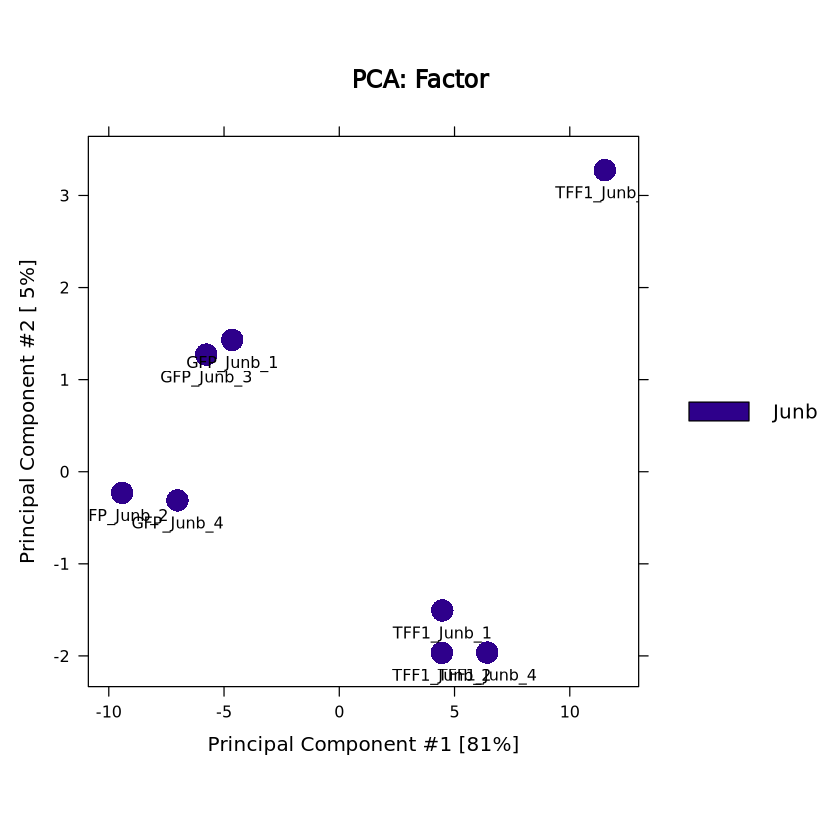

In [6]:
dba.plotPCA(dba_obj,  attributes=DBA_FACTOR, label=DBA_ID)

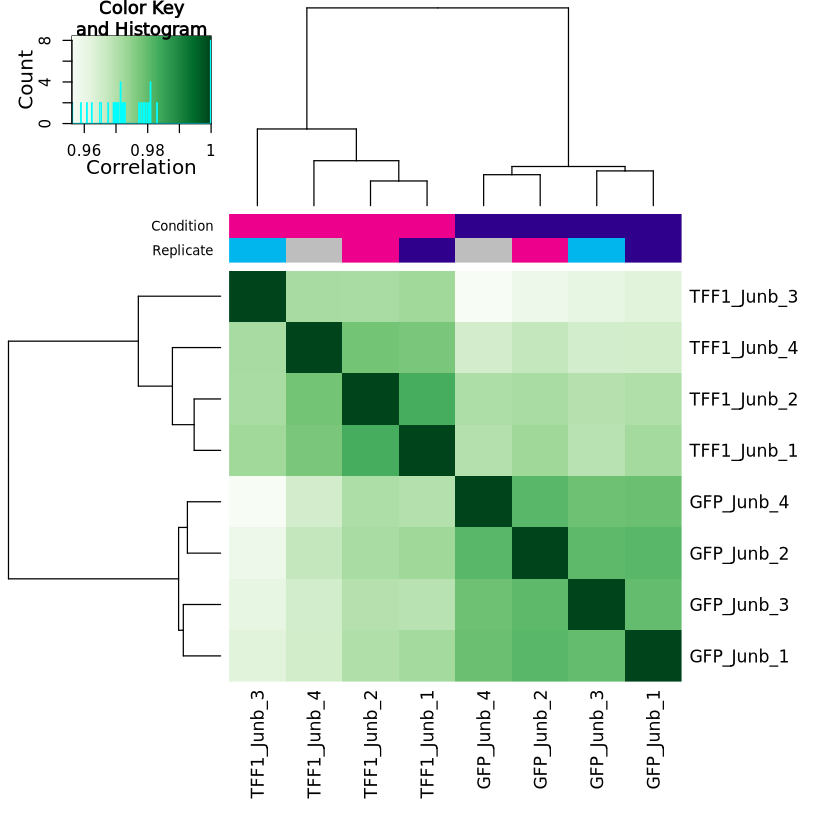

In [7]:
plot(dba_obj)

In [8]:
cts <- dba.peakset(dba_obj, bRetrieve=TRUE, DataType=DBA_DATA_FRAME)
cat('Peaks:', nrow(cts), '\n')
cat('Range of counts across peaks:\n')
print(summary(rowSums(cts[, -(1:3)])))
cat('Samples with zero total counts:\n')
print(colSums(cts[, -(1:3)]))

Peaks: 795 
Range of counts across peaks:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  506.8   913.6  1210.7  1947.0  1807.6 28942.7 
Samples with zero total counts:
 GFP_Junb_1  GFP_Junb_2  GFP_Junb_3  GFP_Junb_4 TFF1_Junb_1 TFF1_Junb_2 
   212970.8    235475.7    216685.2    223883.6    172905.2    173523.4 
TFF1_Junb_3 TFF1_Junb_4 
   148107.0    164353.0 


In [9]:
dba_obj <- dba.normalize(dba_obj)

norm <- dba.normalize(dba_obj, bRetrieve=TRUE)
norm

$norm.method
[1] "lib"

$norm.factors
[1] 0.9149799 1.0438232 0.8415481 0.9019240 1.2071704 1.2097276 0.8511345
[8] 1.0296923

$lib.method
[1] "full"

$lib.sizes
[1] 27618674 31507810 25402134 27224582 36438447 36515636 25691500 31081268

$control.subtract
[1] TRUE

$filter.value
[1] 1

In [10]:
info <- dba.show(dba_obj)
normlibs <- cbind(FullLibSize=norm$lib.sizes, NormFacs=norm$norm.factors,
                  NormLibSize=round(norm$lib.sizes/norm$norm.factors))

rownames(normlibs) <- info$ID
normlibs

,FullLibSize,NormFacs,NormLibSize
GFP_Junb_1,27618674,0.9149799,30185006
GFP_Junb_2,31507810,1.0438232,30185006
GFP_Junb_3,25402134,0.8415481,30185006
GFP_Junb_4,27224582,0.9019240,30185006
TFF1_Junb_1,36438447,1.2071704,30185006
TFF1_Junb_2,36515636,1.2097276,30185006
TFF1_Junb_3,25691500,0.8511345,30185006
TFF1_Junb_4,31081268,1.0296923,30185006


In [11]:
# positive Fold = TFF1-enriched, negative = GFP-enriched
dba_obj <- dba.contrast(
    dba_obj,
    group1 = dba.mask(dba_obj, DBA_CONDITION, 'TFF1'),
    group2 = dba.mask(dba_obj, DBA_CONDITION, 'GFP'),
    name1  = 'TFF1',
    name2  = 'GFP'
)

dba_obj

8 Samples, 795 sites in matrix:
           ID Tissue Factor Condition Replicate    Reads FRiP
1  GFP_Junb_1   Junb   Junb       GFP         1 27618674 0.01
2  GFP_Junb_2   Junb   Junb       GFP         2 31507810 0.01
3  GFP_Junb_3   Junb   Junb       GFP         3 25402134 0.01
4  GFP_Junb_4   Junb   Junb       GFP         4 27224582 0.01
5 TFF1_Junb_1   Junb   Junb      TFF1         1 36438447 0.01
6 TFF1_Junb_2   Junb   Junb      TFF1         2 36515636 0.01
7 TFF1_Junb_3   Junb   Junb      TFF1         3 25691500 0.00
8 TFF1_Junb_4   Junb   Junb      TFF1         4 31081268 0.01

1 Contrast:
  Group Samples Group2 Samples2
1  TFF1       4    GFP        4

In [12]:
#dba_obj$config$th <- 0.5

In [13]:
dba_obj <- dba.analyze(dba_obj)

dba.show(dba_obj, bContrasts=TRUE)

Applying Blacklist/Greylists...

Genome detected: Mmusculus.UCSC.mm10

Applying blacklist...

Removed: 8 of 795 intervals.

Re-normalizing...

Removed 8 (of 795) consensus peaks.

Analyzing...

converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



,Group,Samples,Group2,Samples2,DB.DESeq2
,<chr>,<chr>,<chr>,<chr>,<chr>
1,TFF1,4,GFP,4,683


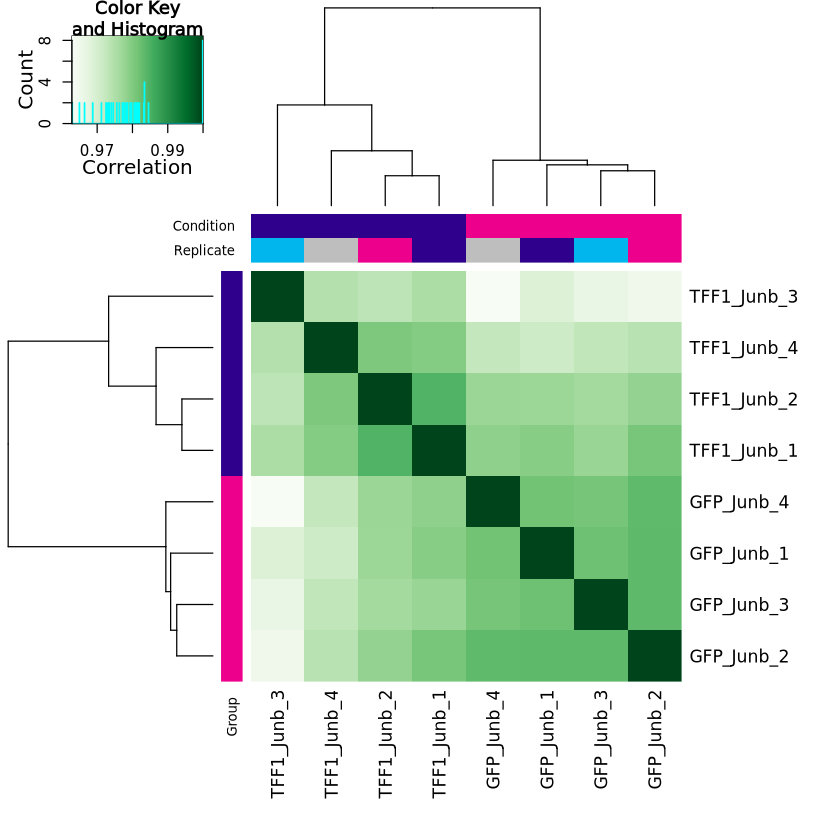

In [14]:
plot(dba_obj, contrast = 1)

In [15]:
dba_obj.DB <- dba.report(dba_obj)
dba_obj.DB

GRanges object with 683 ranges and 6 metadata columns:
      seqnames              ranges strand |      Conc Conc_TFF1  Conc_GFP
         <Rle>           <IRanges>  <Rle> | <numeric> <numeric> <numeric>
  390     chr4 130235450-130288250      * |  10.41991  10.01742  10.73425
  469     chr4 150792800-150810300      * |   9.18107   8.71646   9.53195
  222    chr16   29909800-29917250      * |   7.91116   7.25296   8.36146
  462     chr4 149043150-149086850      * |  10.12560   9.81823  10.37885
  224    chr16   31289750-31293800      * |   7.69234   7.05659   8.13211
  ...      ...                 ...    ... .       ...       ...       ...
  187    chr15   58820550-58825200      * |   7.15113   6.99698   7.29039
  186    chr15   58322150-58326800      * |   6.95944   6.81120   7.09386
  150    chr14   27340150-27343200      * |   6.23368   6.02147   6.41865
  313     chr2   24933200-24938250      * |   7.00814   6.85095   7.14987
  547     chr6   37439650-37443450      * |   6.55674   6

In [16]:
sum(dba_obj.DB$Fold>0)

[1] 0

In [16]:
sum(dba_obj.DB$Fold<0)

[1] 126

In [22]:
# Extract results — th=1 returns all peaks regardless of FDR
res_deseq2 <- dba.report(dba_obj, method=DBA_DESEQ2, th=1)
#res_edger  <- dba.report(dba_obj, method=DBA_EDGER,  th=1)

cat('--- DESeq2 ---\n')
print(head(as.data.frame(res_deseq2)))

sig_d <- res_deseq2[!is.na(res_deseq2$FDR) & res_deseq2$FDR < FDR_THRESH]

cat(sprintf('\nDESeq2: %d total | %d sig | %d TFF1 | %d GFP\n',
    length(res_deseq2), length(sig_d), sum(sig_d$Fold > 0), sum(sig_d$Fold < 0)))

#write.csv(as.data.frame(res_deseq2), file.path(OUT_DIR, paste0(TF, '_deseq2_results.csv')), row.names=FALSE)

# Save significant peak BED files (0-based start)
save_bed <- function(gr, path) {
    if (length(gr) > 0)
        write.table(data.frame(chr=seqnames(gr), start=start(gr)-1L, end=end(gr)),
                    path, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
}
save_bed(sig_d[sig_d$Fold > 0], file.path(OUT_DIR, paste0(TF, '_deseq2_TFF1_enriched.bed')))
save_bed(sig_d[sig_d$Fold < 0], file.path(OUT_DIR, paste0(TF, '_deseq2_GFP_enriched.bed')))

--- DESeq2 ---
    seqnames     start       end  width strand      Conc Conc_TFF1  Conc_GFP
390     chr4 130235450 130288250  52801      * 10.419906 10.017416 10.734252
469     chr4 150792800 150810300  17501      *  9.181075  8.716463  9.531950
222    chr16  29909800  29917250   7451      *  7.911158  7.252961  8.361464
462     chr4 149043150 149086850  43701      * 10.125600  9.818229 10.378846
224    chr16  31289750  31293800   4051      *  7.692339  7.056591  8.132114
435     chr4 139439250 139546200 106951      * 11.454178 11.182506 11.682709
          Fold      p.value          FDR
390 -0.7168365 1.873269e-42 1.474263e-39
469 -0.8154867 5.005017e-29 1.969474e-26
222 -1.1085029 1.485432e-27 3.896783e-25
462 -0.5606173 2.450193e-23 4.820755e-21
224 -1.0755231 1.017205e-21 1.601081e-19
435 -0.5002032 1.665148e-21 2.184119e-19

DESeq2: 787 total | 683 sig | 0 TFF1 | 683 GFP


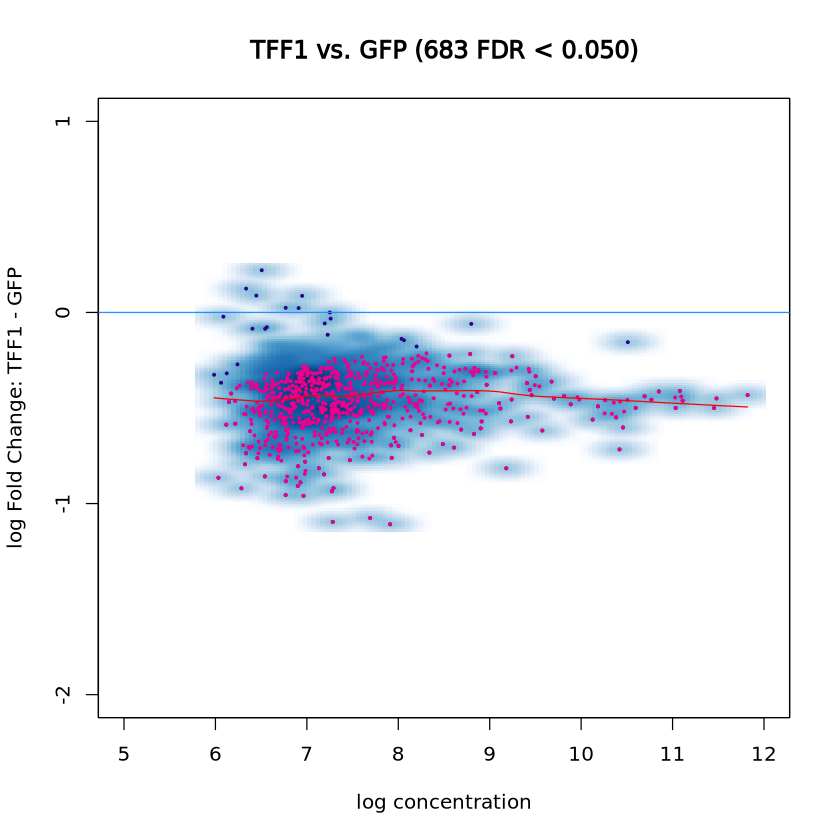

In [18]:
dba.plotMA(dba_obj, method=DBA_DESEQ2)

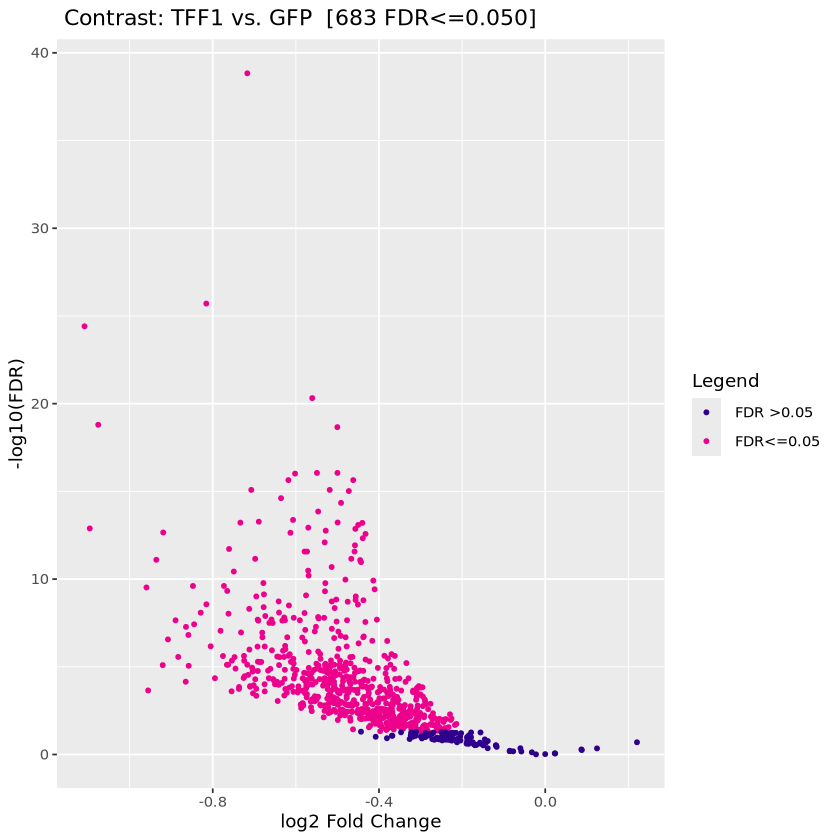

In [19]:
dba.plotVolcano(dba_obj, method=DBA_DESEQ2)

In [20]:
txdb <- makeTxDbFromGFF(GTF, format='gtf')

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
OK



In [23]:
# Annotate all peaks from DESeq2 and edgeR output (th=1, includes non-significant)
# ChIPseeker: TSS window defined in the settings cell (TSS_UP / TSS_DOWN)

annotate_gr <- function(gr, txdb, tss_up, tss_down) {
    anno <- annotatePeak(
        gr,
        TxDb      = txdb,
        tssRegion = c(-tss_up, tss_down),
        annoDb    = 'org.Mm.eg.db'
    )
    df <- as.data.frame(anno)
    names(df)[names(df) == 'p-value'] <- 'pvalue'
    df
}

anno_d <- annotate_gr(res_deseq2, txdb, TSS_UP, TSS_DOWN)

tag <- function(df) {
    df$significant <- !is.na(df$FDR) & df$FDR < FDR_THRESH
    df$direction   <- ifelse(!df$significant, 'NS',
                      ifelse(df$Fold > 0, 'TFF1', 'GFP'))
    df
}
anno_d <- tag(anno_d)

#write.csv(anno_d, file.path(OUT_DIR, paste0(TF, '_deseq2_annotated.csv')), row.names=FALSE)

cat(sprintf('DESeq2: %d total peaks annotated (%d sig)\n', nrow(anno_d), sum(anno_d$significant)))

cat('Annotation columns:', paste(names(anno_d), collapse=', '), '\n\n')
preview_cols <- intersect(
    c('seqnames', 'start', 'end', 'Fold', 'FDR', 'annotation', 'SYMBOL', 'distanceToTSS'),
    names(anno_d)
)
head(anno_d[, preview_cols])

>> preparing features information...		 2026-04-13 12:32:26 
>> identifying nearest features...		 2026-04-13 12:32:26 
>> calculating distance from peak to TSS...	 2026-04-13 12:32:26 
>> assigning genomic annotation...		 2026-04-13 12:32:26 
>> adding gene annotation...			 2026-04-13 12:32:26 


Warning message in annotatePeak(gr, TxDb = txdb, tssRegion = c(-tss_up, tss_down), :
“Unknown ID type, gene annotation will not be added...”


>> assigning chromosome lengths			 2026-04-13 12:32:26 
>> done...					 2026-04-13 12:32:26 
DESeq2: 787 total peaks annotated (683 sig)
Annotation columns: seqnames, start, end, width, strand, Conc, Conc_TFF1, Conc_GFP, Fold, p.value, FDR, annotation, geneChr, geneStart, geneEnd, geneLength, geneStrand, geneId, transcriptId, distanceToTSS, significant, direction 



,seqnames,start,end,Fold,FDR,annotation,distanceToTSS
,<fct>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>
1,chr4,130235450,130288250,-0.7168365,1.474263e-39,Promoter (<=1kb),0
2,chr4,150792800,150810300,-0.8154867,1.969474e-26,Distal Intergenic,44649
3,chr16,29909800,29917250,-1.1085029,3.896783e-25,Distal Intergenic,61874
4,chr4,149043150,149086850,-0.5606173,4.820755e-21,"Exon (NM_019781/Pex14, exon 2 of 9)",12962
5,chr16,31289750,31293800,-1.0755231,1.601081e-19,Distal Intergenic,-14053
6,chr4,139439250,139546200,-0.5002032,2.184119e-19,Promoter (<=1kb),0


>> preparing features information...		 2026-04-13 12:32:28 
>> identifying nearest features...		 2026-04-13 12:32:28 
>> calculating distance from peak to TSS...	 2026-04-13 12:32:29 
>> assigning genomic annotation...		 2026-04-13 12:32:29 
>> assigning chromosome lengths			 2026-04-13 12:32:29 
>> done...					 2026-04-13 12:32:29 
>> preparing features information...		 2026-04-13 12:32:29 
>> identifying nearest features...		 2026-04-13 12:32:29 
>> calculating distance from peak to TSS...	 2026-04-13 12:32:29 
>> assigning genomic annotation...		 2026-04-13 12:32:29 
>> assigning chromosome lengths			 2026-04-13 12:32:30 
>> done...					 2026-04-13 12:32:30 


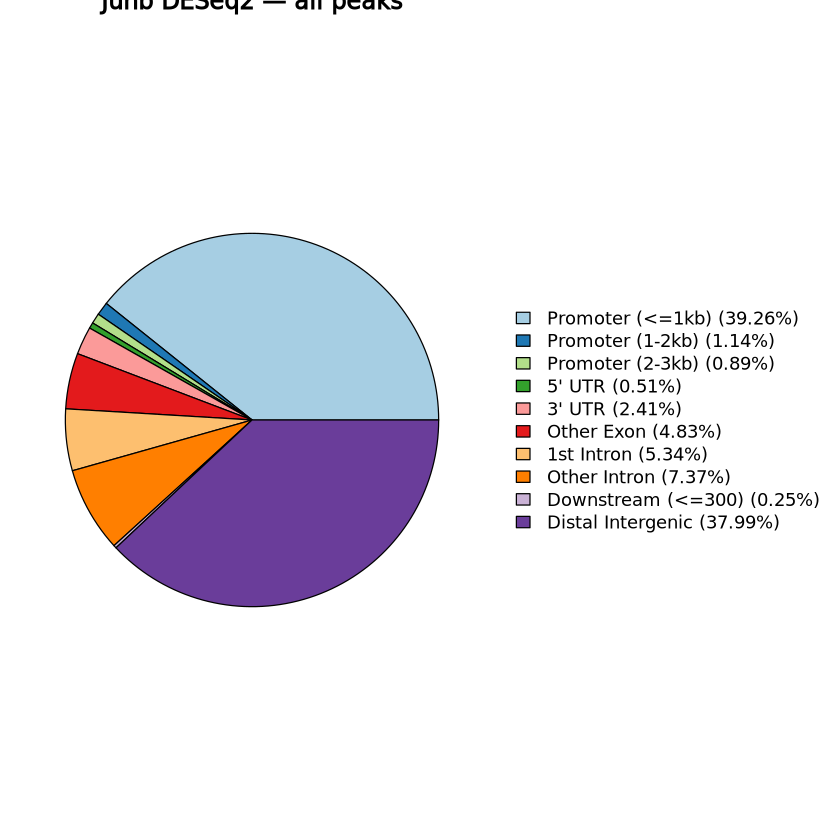

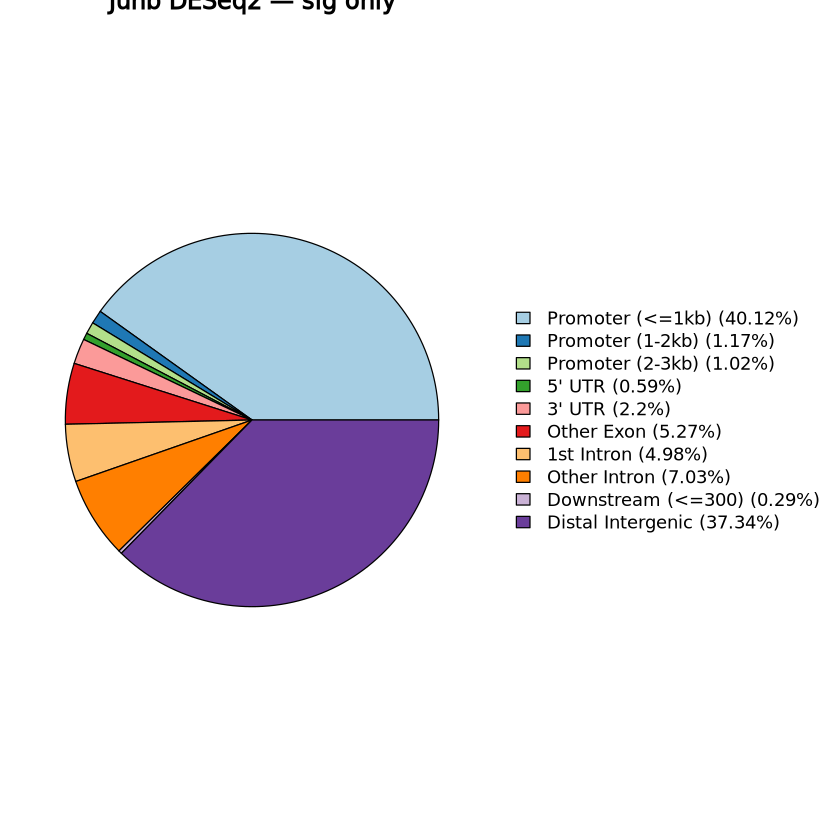

In [24]:

plot_pies <- function(gr_all, gr_sig, label, txdb, tss_up, tss_down) {
    anno_all <- annotatePeak(gr_all, TxDb=txdb, tssRegion=c(-tss_up, tss_down))
    if (length(gr_sig) > 0) {
        par(mfrow=c(1,2))
        plotAnnoPie(anno_all, main=paste(TF, label, '— all peaks'))
        anno_sig <- annotatePeak(gr_sig, TxDb=txdb, tssRegion=c(-tss_up, tss_down))
        plotAnnoPie(anno_sig, main=paste(TF, label, '— sig only'))
    } else {
        par(mfrow=c(1,1))
        plotAnnoPie(anno_all, main=paste(TF, label, '— all peaks (0 sig)'))
    }
}

plot_pies(res_deseq2, sig_d, 'DESeq2', txdb, TSS_UP, TSS_DOWN)

In [25]:
tff1_sig  <- anno_d[!is.na(anno_d$direction) & anno_d$direction == 'TFF1',  ]
gfp_sig <- anno_d[!is.na(anno_d$direction) & anno_d$direction == 'GFP', ]

write.csv(anno_d,    file.path(OUT_DIR, paste0(TF, '_deseq2_all_results.csv')),    row.names=FALSE)
write.csv(tff1_sig,  file.path(OUT_DIR, paste0(TF, '_deseq2_tff1_enriched.csv')),  row.names=FALSE)
write.csv(gfp_sig, file.path(OUT_DIR, paste0(TF, '_deseq2_gfp_enriched.csv')), row.names=FALSE)

cat(sprintf('Saved CSVs to %s/\n  All: %d | TFF1-enriched: %d | GFP-enriched: %d\n',
    OUT_DIR, nrow(anno_d), nrow(tff1_sig), nrow(gfp_sig)))

Saved CSVs to 0_outputs//
  All: 787 | TFF1-enriched: 0 | GFP-enriched: 683
